In [115]:
import numpy as np
import matplotlib.pyplot as plt

In [116]:
class DiscreteSignal:
    def __init__(self,INF):
        self.INF=INF
        self.values=np.zeros(2*INF+1)
    def set_signal_range(self,newINF): #modifies the signal range from -newINF to +newINF
        if newINF<0:
            print('Invalid range')
            return self
        if newINF==self.INF:
            return self
        temp_signal=DiscreteSignal(newINF)
        if newINF<self.INF:
            temp_signal.values=self.values[self.INF-newINF:self.INF-newINF+2*newINF+1]
        elif newINF>self.INF:
            temp_signal.values[newINF-self.INF:newINF-self.INF+2*self.INF+1]=self.values
        return temp_signal
    def set_value_at_time(self,time,value):
        if(np.abs(time)>self.INF):
            self.set_signal_range(np.abs(time))
        self.values[self.INF+time]=value
    def shift_signal(self,shift):
        temp=DiscreteSignal(self.INF+np.abs(shift))
        if shift==0:
            temp.values=np.copy(self.values)
        if shift>0:
            temp.values[2*shift:2*shift+2*self.INF+1]=self.values
        if shift<0:
            temp.values[0:2*self.INF+1]=self.values
        return temp
    def add(self,other):
        newINF=np.max([self.INF,other.INF])
        signal1= self.set_signal_range(newINF)
        signal2= other.set_signal_range(newINF)
        result= DiscreteSignal(newINF)
        result.values=signal1.values+signal2.values
        return result
    def multiply(self,other):
        newINF=np.max([self.INF,other.INF])
        signal1= self.set_signal_range(newINF)
        signal2= other.set_signal_range(newINF)
        result= DiscreteSignal(newINF)
        result.values=signal1.values*signal2.values
        return result
    def multiply_const_scalar(self,scalar):
        result=DiscreteSignal(self.INF)
        result.values=self.values*scalar
        return result
    def plot(self, title=""):
        times=np.arange(-self.INF,self.INF+1)
        plt.stem(times,self.values)
        plt.xlabel("Time")
        plt.ylabel("x[n]")
        plt.title(title)
        plt.grid(True,alpha=0.2)
        # plt.show()
        


In [117]:
# INF=2
# signal=DiscreteSignal(INF)
# signal.set_value_at_time(-2,1)
# signal.set_value_at_time(-1,1)
# signal.set_value_at_time(0,1)
# signal.set_value_at_time(1,1)
# signal.set_value_at_time(2,1)
# # signal.plot()
# # signal=signal.shift_signal(2)
# # signal.plot()
# # signal=signal.shift_signal(-3)
# # signal.plot()
# signal2=signal
# signal2=signal2.set_signal_range(3)
# signal2.plot()
# temp=signal.add(signal2)
# temp.plot()
# temp=signal.multiply(signal2)
# temp.plot()

In [118]:
class ContinuousSignal:
    def __init__(self,func,T_MIN, T_MAX, N):
        self.func=func
        self.T_MIN=T_MIN
        self.T_MAX=T_MAX
        self.N=N
    def shift(self,shift):
        return ContinuousSignal(lambda t: self.func(t-shift),self.T_MAX,self.T_MIN,self.N)
    def add(self,other):
        return ContinuousSignal(lambda t: self.func(t)+other.func(t),self.T_MAX,self.T_MIN,self.N)
    def multiply(self,other):
        return ContinuousSignal(lambda t: self.func(t)*other.func(t),self.T_MAX,self.T_MIN,self.N)
    def multiply_const_factor(self,scalar):
        return ContinuousSignal(lambda t: self.func(t)*scalar,self.T_MAX,self.T_MIN,self.N)
    def plot(self, title=""):
        times=np.linspace(self.T_MIN,self.T_MAX,self.N)
        x_t=self.func(times)
        plt.plot(times,x_t)
        plt.xlabel('Time')
        plt.ylabel('x(t)')
        plt.title(title)
        plt.grid(True,alpha=0.2)
        # plt.show()

In [119]:
# signal=ContinuousSignal(np.sin,-20,+20,400001)
# signal.plot()
# signal=signal.shift(-np.pi/3)
# signal.plot()

In [120]:
class LTI_Discrete_class:
    def __init__(self,impulse_response: DiscreteSignal):
        self.impulse_response=impulse_response
    def linear_combination_of_impulses(self,input_signal):
        impulses=[]
        coefficients= input_signal.values
        for i in range(0,2*input_signal.INF+1):
            impulse=DiscreteSignal(self.INF)
            impulse.values[i]=1
            impulses.append(impulse)
        return impulses,coefficients
    def output(self,input_signal):
        output_signal=None
        for k in range(-input_signal.INF, input_signal.INF+1):
            shifted_impulse=self.impulse_response.shift_signal(k)
            scaled_signal=shifted_impulse.multiply_const_scalar(input_signal.values[k+input_signal.INF])
            if output_signal:
                output_signal=output_signal.add(scaled_signal)
            else:
                output_signal=scaled_signal
        return output_signal

In [121]:
# impulse_response=DiscreteSignal(5)
# impulse_response.set_value_at_time(0,1)
# impulse_response.set_value_at_time(1,1)
# impulse_response.set_value_at_time(2,1)
# impulse_response.plot("Impulse Response")
# system=LTI_Discrete_class(impulse_response)
# input_signal=DiscreteSignal(5)
# input_signal.set_value_at_time(0,0.5)
# input_signal.set_value_at_time(1,2)
# input_signal.plot()
# output_signal=system.output(input_signal)
# output_signal.plot()

In [ ]:
class LTI_Continuous:
    def __init__(self, impulse_response:ContinuousSignal):
        self.impulse_response=impulse_response
    def linear_combination_of_impulses(self, input_signal:ContinuousSignal,delta):
        impulses=[]
        coefficients=[]
        for k in np.arange(input_signal.T_MIN,input_signal.T_MAX+1,delta):
            impulse=self.impulse_response.shift(k)
            impulses.append(impulse)
            coefficients.append(input_signal.func(k))
        return impulses,coefficients
    def output_approx(self, input_signal:ContinuousSignal,delta):
        impulses, coefficients= self.linear_combination_of_impulses(input_signal,delta)
        output_signal=None
        for impulse, coefficient in zip(impulses,coefficients):
            impulse:ContinuousSignal
            scaled_impulse=impulse.multiply_const_factor(coefficient)
            output_signal:ContinuousSignal
            if output_signal:
                output_signal=output_signal.add(scaled_impulse)
            else:
                output_signal=scaled_impulse
        return output_signal

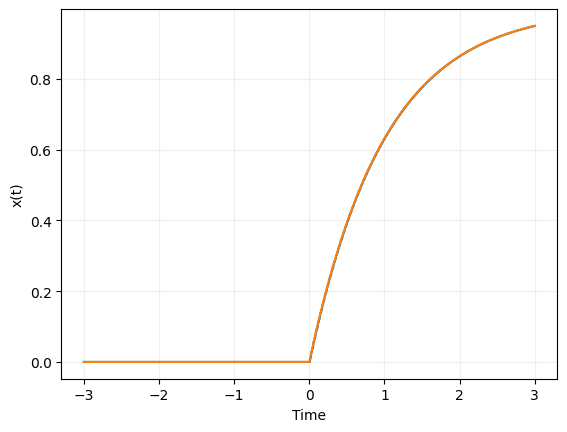

In [130]:
def func(t:np.ndarray):
    return np.where(t>=0,np.exp(-t),0)
def func2(t:np.ndarray):
    return np.where(t>=0,1-np.exp(-t),0)
signal=ContinuousSignal(func2,-3,3,1001)
delta=0.01
impulse_response=ContinuousSignal(lambda t: (t>=0)&(t<=delta),-3,+3,1001)
system=LTI_Continuous(impulse_response)
impulses,coefficients=system.linear_combination_of_impulses(signal,delta)
stairCase=None
for impulse, coefficient in zip(impulses,coefficients):
    if stairCase:
        stairCase=stairCase.add(impulse.multiply_const_factor(coefficient))
    else:
        stairCase=impulse.multiply_const_factor(coefficient)
stairCase.plot()
signal.plot()
plt.show()
